<a href="https://colab.research.google.com/github/202503660-ai/NLP_for_SocialScience/blob/Zero-Shot-Performance-and-Limitations-Analysis-of-Korean-Sentiment-Recognition-in-Multilingual-LLM/preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import files

# 1. 대용량 파일 다운로드 (asgmt2에 사용된 링크 기준, 필요시 파일 ID나 파일명을 바꾸어 사용하세요)
# 만약 이미 코랩에 파일을 업로드했다면 이 부분은 실행하지 않거나 주석 처리하셔도 됩니다.
file_id = "1IsortNICOU7JPyWtNCm_8Yzqo8UqYDhp"  # asgmt2_text_preprocessing 기준 파일 ID
file_path = "/content/result.xlsx"

if not os.path.exists(file_path):
    print("데이터 파일을 다운로드합니다...")
    !gdown --id {file_id} -O {file_path}

# 2. 엑셀 파일 로드 (openpyxl 라이브러리 필요)
print("엑셀 파일을 읽어오는 중입니다. 용량이 커서 시간이 조금 걸릴 수 있습니다...")
df = pd.read_excel(file_path)
print(f"데이터 로드 완료! 원본 데이터 모양: {df.shape}")


# 3. 분류 기준 함수 정의 및 적용

# [기준 1] 감정 세기 분류 (절댓값 0.4, 0.7 기준)
def categorize_intensity(score):
    if pd.isna(score):
        return '확인불가'
    abs_score = abs(score)
    if abs_score < 0.4:
        return '약함'
    elif abs_score < 0.7:
        return '보통'
    else:
        return '강함'

df['감정_세기'] = df['추론_감성_점수'].apply(categorize_intensity)


# [기준 2] 감성 극성 분류 (긍정 / 부정 / 중립)
def categorize_polarity(score):
    if pd.isna(score):
        return '확인불가'
    if score > 0:
        return '긍정'
    elif score < 0:
        return '부정'
    else:
        return '중립'

df['감성_극성'] = df['추론_감성_점수'].apply(categorize_polarity)


# [기준 3] 문장 길이 분류 (단문 / 중문 / 장문)
def categorize_length(text):
    if pd.isna(text):
        return '데이터없음'
    length = len(str(text))
    if length < 50:
        return '단문(50자 미만)'
    elif length <= 100:
        return '중문(50자~100자)'
    else:
        return '장문(100자 초과)'

df['문장_길이_분류'] = df['사람문장_통합'].apply(categorize_length)


# [기준 4] 감정 종합 분류 (감정 대분류 + 감정 세기 결합)
# 예: 불안_강함, 당황_보통 등
df['감정_종합_분류'] = df['감정_대분류'].astype(str) + '_' + df['감정_세기']


# 4. 분류 결과 간단 요약 출력 확인
print("\n" + "="*40)
print("📊 새로 추가된 분류 기준별 데이터 분포 요약")
print("="*40)
print("\n[감정 세기 비율]")
print(df['감정_세기'].value_counts(dropna=False))
print("\n[감성 극성 비율]")
print(df['감성_극성'].value_counts(dropna=False))
print("\n[문장 길이 분류 비율]")
print(df['문장_길이_분류'].value_counts(dropna=False))


# 5. 새로운 엑셀 파일로 추출 및 내 컴퓨터로 다운로드
output_path = '/content/processed_emotion_data.xlsx'
print("\n새로운 분류가 추가된 엑셀 파일을 생성 중입니다...")
df.to_excel(output_path, index=False)
print(f"파일 생성 완료! 저장 경로: {output_path}")

# 웹 브라우저를 통해 PC로 자동 다운로드 실행
print("로컬 컴퓨터로 파일을 다운로드합니다...")
files.download(output_path)

데이터 파일을 다운로드합니다...
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1IsortNICOU7JPyWtNCm_8Yzqo8UqYDhp
To: /content/result.xlsx
100% 15.3M/15.3M [00:00<00:00, 67.9MB/s]
엑셀 파일을 읽어오는 중입니다. 용량이 커서 시간이 조금 걸릴 수 있습니다...
데이터 로드 완료! 원본 데이터 모양: (58271, 14)

📊 새로 추가된 분류 기준별 데이터 분포 요약

[감정 세기 비율]
감정_세기
보통    24388
약함    17719
강함    16164
Name: count, dtype: int64

[감성 극성 비율]
감성_극성
부정    46530
긍정    11734
중립        7
Name: count, dtype: int64

[문장 길이 분류 비율]
문장_길이_분류
장문(100자 초과)     30394
중문(50자~100자)    25631
단문(50자 미만)       2246
Name: count, dtype: int64

새로운 분류가 추가된 엑셀 파일을 생성 중입니다...
파일 생성 완료! 저장 경로: /content/processed_emotion_data.xlsx
로컬 컴퓨터로 파일을 다운로드합니다...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

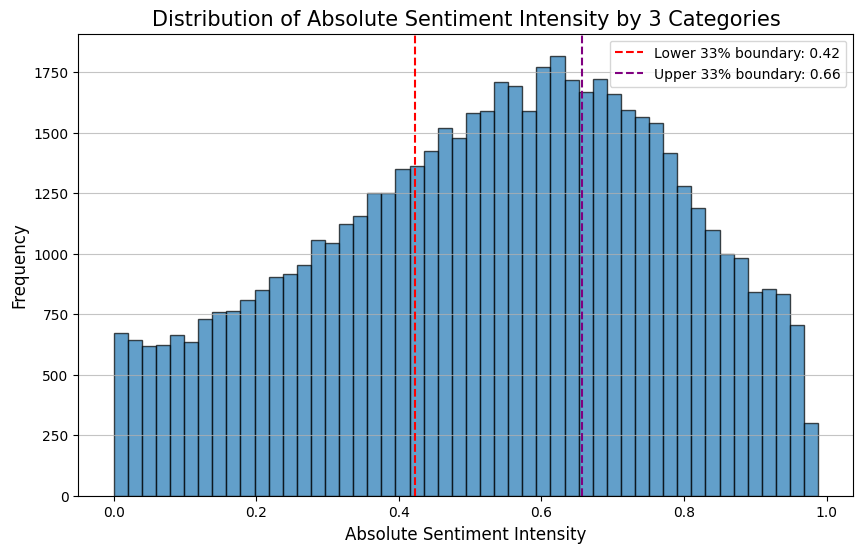

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 감정 세기(절댓값) 계산
absolute_sentiment_scores = df['추론_감성_점수'].abs().dropna()

# 2. 33번째, 66번째 백분위수 계산 (세 그룹으로 나누기 위해)
percentile_33 = np.percentile(absolute_sentiment_scores, 33)
percentile_66 = np.percentile(absolute_sentiment_scores, 66)

# 3. 분포 시각화 (히스토그램)
plt.figure(figsize=(10, 6))
plt.hist(absolute_sentiment_scores, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Absolute Sentiment Intensity by 3 Categories', fontsize=15)
plt.xlabel('Absolute Sentiment Intensity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)

# 4. 3분할 경계선 추가
plt.axvline(percentile_33, color='red', linestyle='dashed', linewidth=1.5, label=f'Lower 33% boundary: {percentile_33:.2f}')
plt.axvline(percentile_66, color='purple', linestyle='dashed', linewidth=1.5, label=f'Upper 33% boundary: {percentile_66:.2f}')

plt.legend()
plt.show()

In [ ]:
# '감정_세기_3분할' 열 생성

# 33번째, 66번째 백분위수 (Q9D78fvxG5Wv 셀에서 계산된 값 활용)
# percentile_33, percentile_66 변수는 이미 kernel state에 있습니다.

# 감정 세기(절댓값)를 세 그룹으로 분류하는 함수 정의
def categorize_by_percentile(score):
    if pd.isna(score):
        return '확인불가'
    abs_score = abs(score)
    if abs_score <= percentile_33:
        return '하위 33% (Low)'
    elif abs_score <= percentile_66:
        return '중간 33% (Medium)'
    else:
        return '상위 33% (High)'

# 새로운 분류 열 추가
df['감정_세기_3분할'] = df['추론_감성_점수'].apply(categorize_by_percentile)

print("[감정 세기 3분할 비율]")
print(df['감정_세기_3분할'].value_counts(dropna=False))

[감정 세기 3분할 비율]
감정_세기_3분할
상위 33% (High)      19812
하위 33% (Low)       19230
중간 33% (Medium)    19229
Name: count, dtype: int64


In [ ]:
from google.colab import files

# 파일을 저장할 분류 기준 열 목록
categorization_columns_for_splitting = [
    '감정_세기',
    '감성_극성',
    '문장_길이_분류',
    '감정_세기_3분할'
]

print("각 분류 기준별 카테고리 파일 저장 및 다운로드 시작...")

for col_name in categorization_columns_for_splitting:
    print(f"\n>>> '{col_name}' 기준으로 파일 분할 및 생성 중...")
    unique_categories = df[col_name].dropna().unique()

    for category in unique_categories:
        # 해당 카테고리에 해당하는 데이터 필터링
        df_filtered = df[df[col_name] == category].copy()

        if not df_filtered.empty:
            # 파일 이름 설정 (한글 문제 및 파일명 규칙을 고려하여 영문으로 대체 및 정리)
            safe_col_name_part = col_name.replace(' ', '_').replace('(', '').replace(')', '').replace('%', '').replace('감정_세기', 'Sentiment_Intensity').replace('감성_극성', 'Sentiment_Polarity').replace('문장_길이_분류', 'Sentence_Length').replace('감정_세기_3분할', 'Sentiment_Intensity_3_Categories')
            safe_category_name_part = str(category).replace(' ', '_').replace('(', '').replace(')', '').replace('%', '').replace('/', '_').replace('~', '_').replace('<', 'less_than').replace('>', 'greater_than').replace('초과', 'over').replace('미만', 'under').replace('이상', 'over').replace('이하', 'under').replace('강함', 'Strong').replace('보통', 'Medium').replace('약함', 'Weak').replace('긍정', 'Positive').replace('부정', 'Negative').replace('중립', 'Neutral').replace('단문', 'Short').replace('중문', 'Medium_Length').replace('장문', 'Long').replace('하위_33%', 'Low_33').replace('중간_33%', 'Mid_33').replace('상위_33%', 'High_33')

            output_filename = f'{safe_col_name_part}_{safe_category_name_part}_data.xlsx'

            # DataFrame을 해당 기준으로 저장
            df_filtered.to_excel(output_filename, index=False)
            print(f"  파일 저장 완료: {output_filename} (행 수: {len(df_filtered)})")

            # 파일 다운로드
            files.download(output_filename)
            print(f"  '{output_filename}' 파일 다운로드 요청 완료.")
        else:
            print(f"  '{col_name}'의 카테고리 '{category}'에 해당하는 데이터가 없어 파일을 생성하지 않습니다.")

print("\n모든 분류 기준별 카테고리 파일 저장 및 다운로드 완료!")

각 분류 기준별 카테고리 파일 저장 및 다운로드 시작...

>>> '감정_세기' 기준으로 파일 분할 및 생성 중...
  파일 저장 완료: Sentiment_Intensity_Medium_data.xlsx (행 수: 24388)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  'Sentiment_Intensity_Medium_data.xlsx' 파일 다운로드 요청 완료.
  파일 저장 완료: Sentiment_Intensity_Weak_data.xlsx (행 수: 17719)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  'Sentiment_Intensity_Weak_data.xlsx' 파일 다운로드 요청 완료.


KeyboardInterrupt: 